In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
from torchsummary import summary
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10


/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
transform=transforms.Compose([
   
    transforms.RandomHorizontalFlip(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),             
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)
    ) 
])

In [3]:
cifar10_train = CIFAR10(root='./data', train=True, download=True, transform=transform)
cifar10_test = CIFAR10(root='./data', train=False, download=True, transform=transform)

Files already downloaded and verified
Files already downloaded and verified


In [4]:
model_algo="alexnet"

In [5]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append('/home/pcdm/Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [6]:
images=CifarDataset(cifar10_train,decision_mode=False)
generator = torch.Generator()
generator.manual_seed(125)

size = len(images)
valid_size = int(0.2 * size)
test_size=int(0.1*size)
train_size = int(size - test_size-valid_size)

trainset, validset,test_set = random_split(images, (train_size, valid_size,test_size), generator=generator)

In [7]:
valid_size

10000

In [8]:
train_size

35000

In [9]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

In [10]:
# model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
model_0 = torch.load(f'model_{model_algo}_0_4.pth')

In [11]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.08411705599427223, 0.9740857142857143)

In [12]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(0.2882693930566311, 0.9045)

In [13]:
r=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(0)
p=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)

In [14]:
each_accu=2*p*r/(p+r)
each_accu

airplane      0.976556
automobile    0.984159
bird          0.971437
cat           0.947553
deer          0.976244
dog           0.950607
frog          0.986569
horse         0.976986
ship          0.988799
truck         0.981196
dtype: float64

In [15]:
# each_accu=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)
# each_accu

In [16]:
targetF=[x  for x in each_accu.nsmallest(4).index.map(trainset.dataset.classess)]
targetF

[3, 5, 2, 4]

In [17]:
 #將資料切分成true and false
def split_data(model_0,data_dl,split_mode):
    model_0.eval()
    indexF=[]
    indexT=[]
    with torch.no_grad():
        for (data,target,idx) in data_dl:
            data,target=data.cuda(),target.cuda()
            out = model_0(data)
            _, y_pred_tag = torch.max(out, dim = 1) 
            criterion = nn.CrossEntropyLoss(reduction='none')
            loss = criterion(out, target)
            softmax = torch.softmax(out, dim=1)
            # print(loss)
            for idx,loss,t,pred ,softmax in zip(idx,loss,target,y_pred_tag,softmax):
                if(split_mode[0]=='loss'):    
                    if(loss>split_mode[1]):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)

                    else:
                        indexT.append(idx.cpu().numpy().item())  


                elif(split_mode[0]=='classaccu'):
                    if(t in split_mode[1]):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                        if(t in [6,4,7,2]):
                            indexT.append(idx.cpu().numpy().item()) 
                            
                    else:
                        indexT.append(idx.cpu().numpy().item()) 
                        if(t in [6,4,7,2]):
                            indexF.append(idx.cpu().numpy().item()) 
                            
            torch.cuda.empty_cache() 
        return indexF,indexT

In [18]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]

split_mode=('loss',0.01)
indexF,indexT=split_data(model_0,train_dl,split_mode)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)

Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)

len(indexF),len(indexT)

(10916, 24084)

In [19]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split_mode)
len(indexF_v),len(indexT_v)

(3825, 6175)

In [20]:
#decision set
def decision_split(data_dl,model_0):
    flat_data=[]
    flat_true=[]
    with torch.no_grad():

        model_0.eval()   

        for data, target,idx in data_dl:

            data,target=data.to(device),target.to(device)
            out= model_0(data)
            softmax = torch.softmax(out, dim=1)
            _, y_pred_tag = torch.max(out, dim = 1) 

            for i,d,t in zip(idx,data,target):
                # if(t!=0):
                flat_true.append(int(data_dl.dataset.dataset.flag[i]))
                flat_data.append(d.cpu().numpy()) 
            
    return flat_data,flat_true

In [21]:
d_data,d_target=decision_split(train_dl,model_0)
d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [22]:
decisionset=DecisionDataset(d_data,d_target)
decisionset_v=DecisionDataset(d_v_data,d_v_target)

In [23]:
#將模型建立框架後並訓練
def model_train(model_algo,train_dl,valid_dl,data_name,epochs,class_weight=None):

    if(data_name=="decision"):
        # model=model_create(model_algo,data_name,2)
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,2)
    elif(data_name=='T'or data_name=='F' or data_name=='F_f'or data_name=='T_f'):
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,len(train_dl.dataset.dataset.classes))

    else:
        model=model_create(model_algo,data_name,len(train_dl.dataset.dataset.classes))

    if(model_algo=='googlenet' or model_algo=='resnet18' or model_algo=='inception_v3' ):
        model_fc_layer=model.fc
    elif(model_algo=='efficientnet_b7' or model_algo=='mobilenet_v2'):
        model_fc_layer=model.classifier[1]
    else:
        model_fc_layer=model.classifier[6]
    # for param in model.parameters():
    #     param.requires_grad = False

    # for param in model_fc_layer.parameters():
    #     param.requires_grad = True

    if(data_name=="decision"):
        optim = torch.optim.Adam(model.classifier[6].parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss() 
        # dense1 = nn.Linear(9216, 224 * 224 * 3)
        # reshape = nn.Unflatten(-1,(3,224, 224))
        # model=nn.Sequential(dense1,reshape,model)
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    else:   
        optim = torch.optim.Adam(model.classifier.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    # torch.save(model, f"model_{model_algo}_{data_name}.pth")
    torch.cuda.empty_cache() 
    return model


Epoch=0,train_loss=0.37407383805002486,train_accu=0.8459142857142857
Epoch=0,valid_loss=0.35520088658332827,valid_accu=0.8498
0
Epoch=1,train_loss=0.34537319693565366,train_accu=0.8554
Epoch=1,valid_loss=0.3242295897006989,valid_accu=0.8581
0
Epoch=2,train_loss=0.32996174524852206,train_accu=0.8628571428571429
Epoch=2,valid_loss=0.3074273351430893,valid_accu=0.868
0
Epoch=3,train_loss=0.3197949331487928,train_accu=0.8687428571428571
Epoch=3,valid_loss=0.29749056828022,valid_accu=0.8741
0
Epoch=4,train_loss=0.30897082882608684,train_accu=0.8748571428571429
Epoch=4,valid_loss=0.2896002521276474,valid_accu=0.8798
0
Epoch=5,train_loss=0.3140682114192418,train_accu=0.8703142857142857
Epoch=5,valid_loss=0.28405328226089477,valid_accu=0.8812
0
Epoch=6,train_loss=0.30054946214812145,train_accu=0.8790285714285714
Epoch=6,valid_loss=0.2866466891050339,valid_accu=0.8758
Epoch=7,train_loss=0.30357349395411354,train_accu=0.8780571428571429
Epoch=7,valid_loss=0.2783285924911499,valid_accu=0.8843
0
E

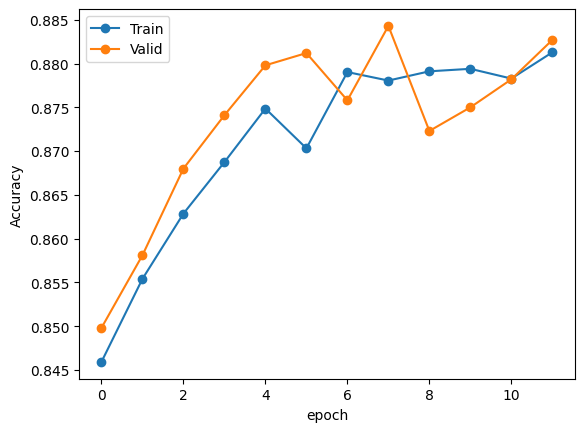

In [24]:
from torchsampler import ImbalancedDatasetSampler
decision_dl = DataLoader(decisionset, batch_size=32,sampler=ImbalancedDatasetSampler(decisionset))
decision_v_dl = DataLoader(decisionset_v, batch_size=32)
model_decision=model_train(model_algo,decision_dl,decision_v_dl,"decision",70)

In [25]:
Fdataset_v=Subset(images, indexF_v)
Tdataset_v=Subset(images, indexT_v)

Fdl_v=DataLoader(Fdataset_v, shuffle=True, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=True, batch_size=batch_size)

Epoch=0,train_loss=0.005087965548152735,train_accu=0.9989619664507556
Epoch=0,valid_loss=0.005156419645936694,valid_accu=0.9978947368421053
0
Epoch=1,train_loss=0.002334615365202659,train_accu=0.999086530476665
Epoch=1,valid_loss=0.004213042609837195,valid_accu=0.9982186234817814
0
Epoch=2,train_loss=0.0018286589458605283,train_accu=0.9992941371865138
Epoch=2,valid_loss=0.005585352877295907,valid_accu=0.9983805668016195
0
Epoch=3,train_loss=0.002365796516698662,train_accu=0.9994602225543929
Epoch=3,valid_loss=0.004545028919507836,valid_accu=0.9985425101214574
0
Epoch=4,train_loss=0.003017163450374701,train_accu=0.999086530476665
Epoch=4,valid_loss=0.007634643433714335,valid_accu=0.997085020242915
Epoch=5,train_loss=0.0017961781703211739,train_accu=0.9995432652383325
Epoch=5,valid_loss=0.004512497528210729,valid_accu=0.9982186234817814
Epoch=6,train_loss=0.0023677336950085315,train_accu=0.9990034877927254
Epoch=6,valid_loss=0.009335497211220865,valid_accu=0.997246963562753
Epoch=7,train

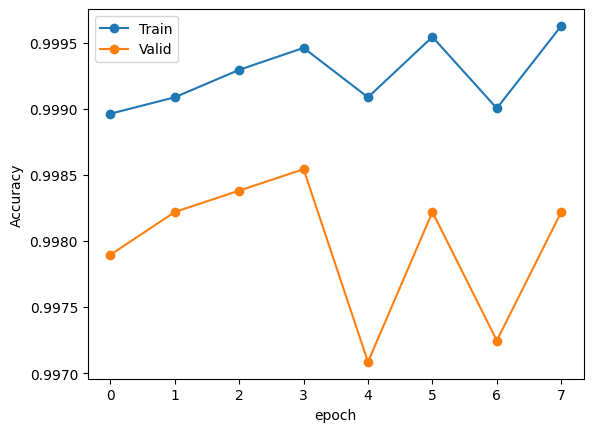

In [26]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

Epoch=0,train_loss=0.17577576528198555,train_accu=0.9449432026383291
Epoch=0,valid_loss=0.7047173517513898,valid_accu=0.7733333333333333
0
Epoch=1,train_loss=0.1165172276299545,train_accu=0.9662880175888604
Epoch=1,valid_loss=0.7413789978837655,valid_accu=0.7592156862745097
Epoch=2,train_loss=0.07944363742985225,train_accu=0.9789300109930378
Epoch=2,valid_loss=0.7278814766453762,valid_accu=0.7798692810457516
0
Epoch=3,train_loss=0.06583418886181679,train_accu=0.9794796628801758
Epoch=3,valid_loss=0.8162367794560451,valid_accu=0.781437908496732
0
Epoch=4,train_loss=0.04091088761503512,train_accu=0.9907475265665079
Epoch=4,valid_loss=0.8073835310437321,valid_accu=0.7822222222222223
0
Epoch=5,train_loss=0.030817715813740768,train_accu=0.9936790032979114
Epoch=5,valid_loss=0.8540821585935705,valid_accu=0.7803921568627451
Epoch=6,train_loss=0.018656405620447562,train_accu=0.9962440454378894
Epoch=6,valid_loss=0.8845383423449946,valid_accu=0.7793464052287582
Epoch=7,train_loss=0.016078710331

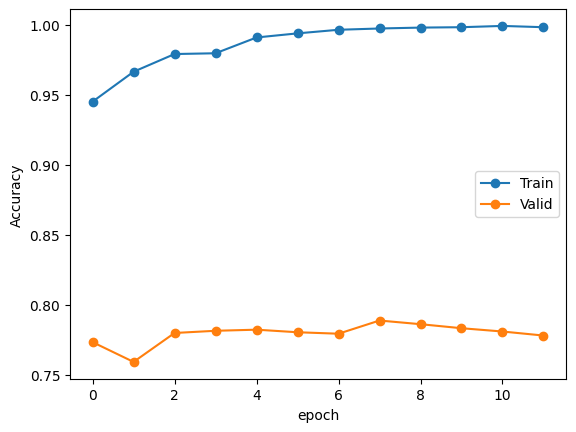

In [27]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [28]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,decision_dl,len(decisionset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(0.298852561385291, 0.8791142857142857)

In [29]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,decision_v_dl,len(decisionset_v),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(0.2783285924911499, 0.8843)

In [30]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.0027712126606866507, 0.9992941371865138)

In [31]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.016198088869963698, 0.9968853059728838)

In [32]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(0.00501559955444732, 0.9988663967611336)

In [33]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(0.8319819288939433, 0.7835294117647059)

In [34]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d,sum

(0.007120144134314199, 0.9982571428571428, 10916)

In [35]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum

(0.3290631993740797, 0.9178, 3825)

In [36]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_train_loss,total_train_accu,sum_F,sum_T

(0.022885195593986593, 0.9957428571428572, 12245, 22755)

In [37]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_valid_loss,total_valid_accu,sum_F,sum_T

(0.397270507773757, 0.9132, 3899, 6101)

In [38]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_valid_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [39]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_without_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
print(f'targetF={targetF}')
df

targetF=[3, 5, 2, 4]


,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.084117,0.974086,0.288269,0.904500
1,Model_Decision,0.298853,0.879114,0.278329,0.884300
2,Model_T,0.002771,0.999294,0.005016,0.998866
3,Model_F,0.016198,0.996885,0.831982,0.783529
4,Total_Model,0.022885,0.995743,0.397271,0.913200
5,Total_Model_without_decision,0.007120,0.998257,0.329063,0.917800


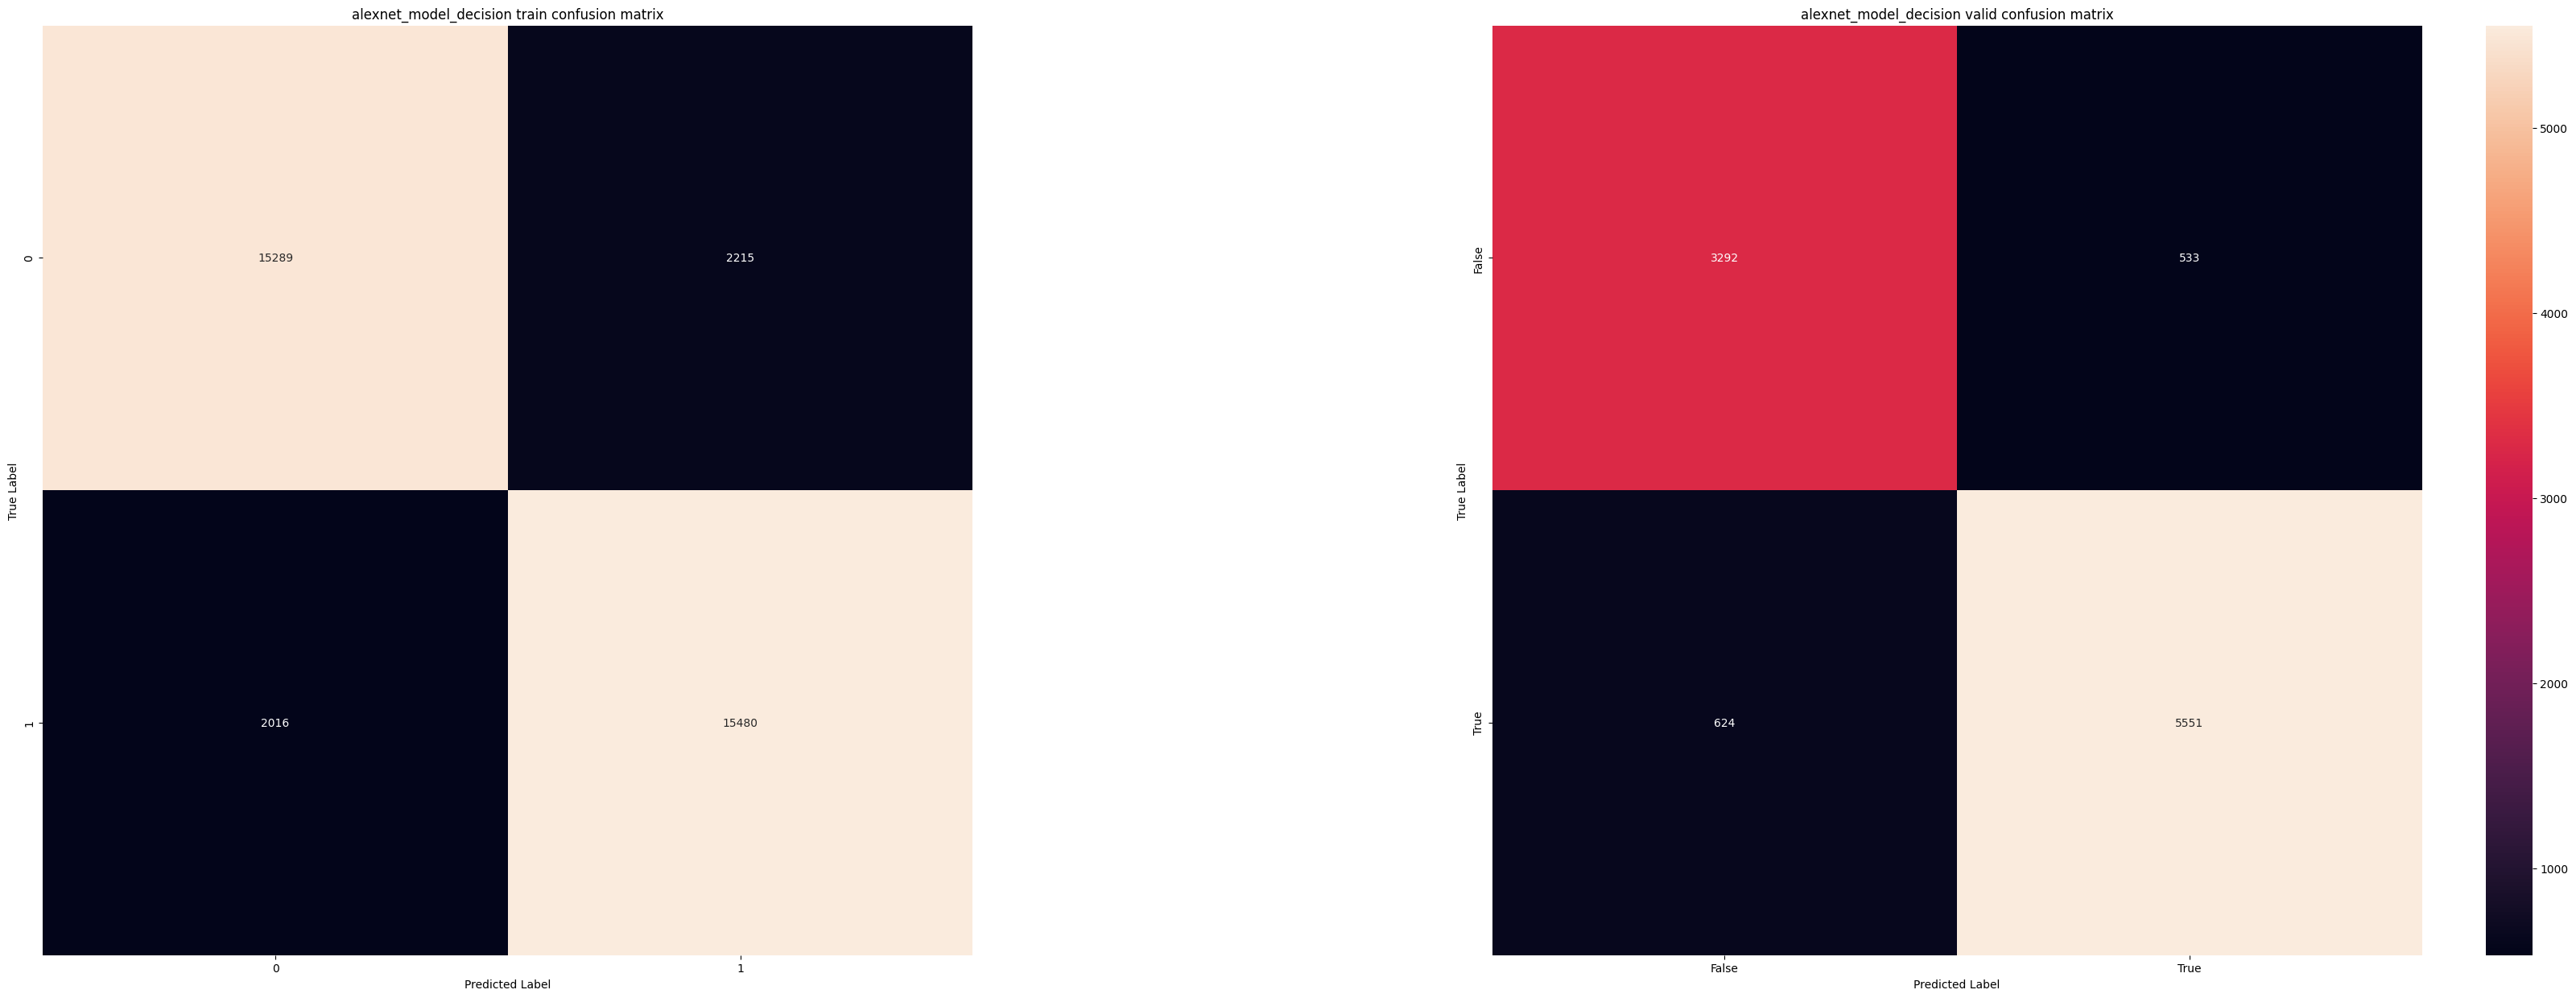

In [40]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)

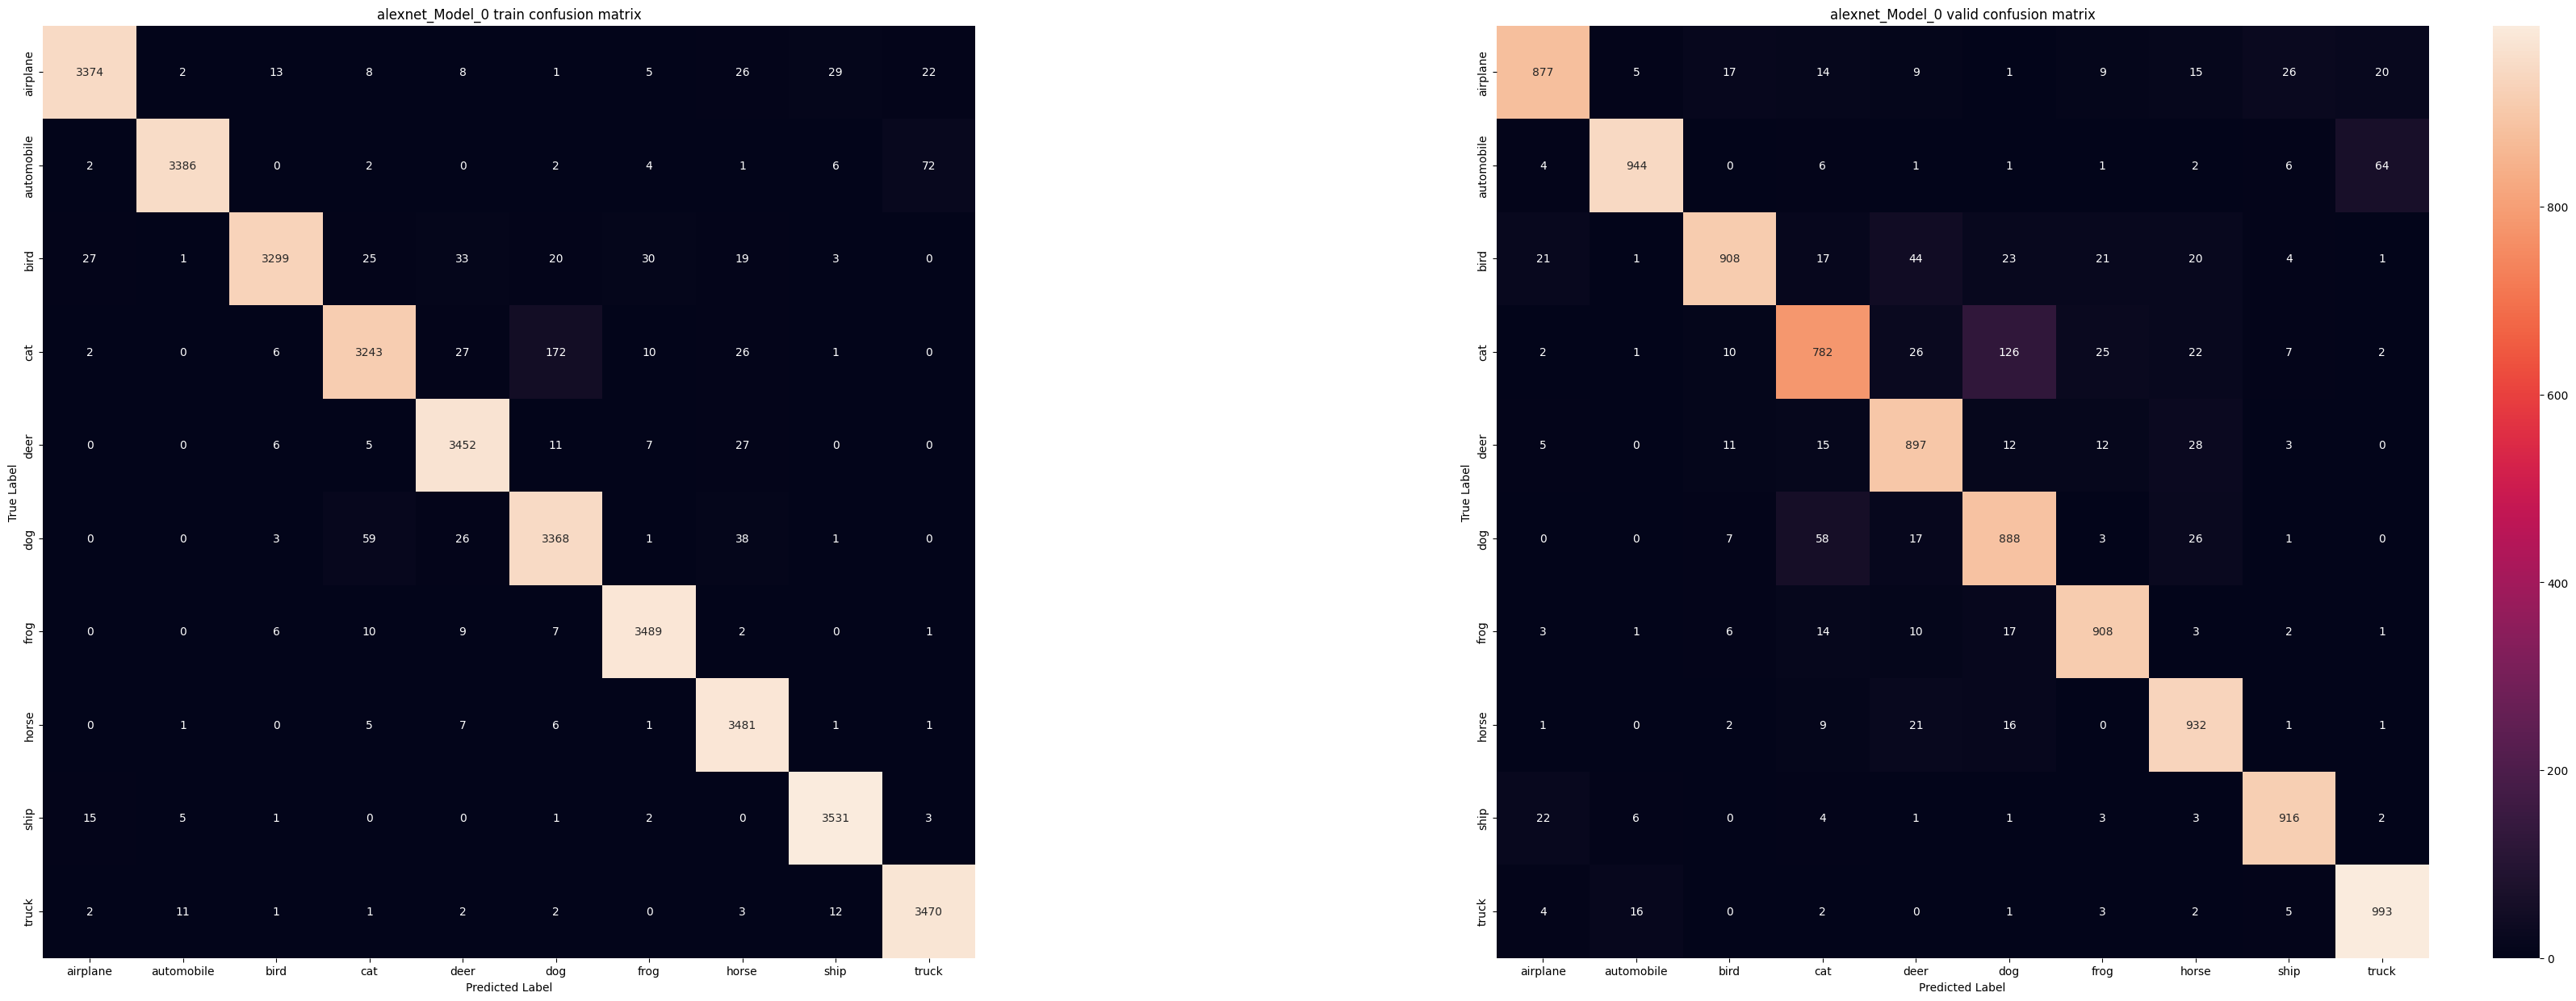

In [41]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

In [42]:
def calculate_confusion(confusion_matrix, N):
    n_classes = confusion_matrix.shape[0]
    confusion_degrees = np.zeros((n_classes, n_classes), dtype=float)
    for i in range(n_classes):
        for j in range(n_classes):
            if i != j:
                degree = (confusion_matrix.iloc[i, j] / np.sum(confusion_matrix.iloc[i])) + \
                        (confusion_matrix.iloc[j, i] / np.sum(confusion_matrix.iloc[j]))
                confusion_degrees[i, j] = degree
    
    # 只检查下三角的元素
    indices = np.tril_indices_from(confusion_degrees, k=-1)
    flat_indices = np.argsort(confusion_degrees[indices])[::-1]
    row_indices = indices[0][flat_indices]
    col_indices = indices[1][flat_indices]
    
    top_elements = confusion_degrees[row_indices, col_indices]
    top_positions = list(zip(row_indices, col_indices))

    print("Top", N, "Elements:")
    print(top_elements[:N])
    print("Top", N, "Positions:")
    print(top_positions[:N])
    
    return top_elements, top_positions

In [43]:
top_elements, top_positions=calculate_confusion(confusion_matrix_train,N=15)

Top 15 Elements:
[0.0662025  0.02385869 0.01258238 0.01253007 0.0115373  0.01125623
 0.01057276 0.01038066 0.00969498 0.00916836 0.00895238 0.00888361
 0.00745413 0.00687812 0.00664349]
Top 15 Positions:
[(5, 3), (9, 1), (7, 5), (8, 0), (2, 0), (4, 2), (5, 4), (6, 2), (7, 4), (4, 3), (3, 2), (7, 3), (7, 0), (9, 0), (5, 2)]


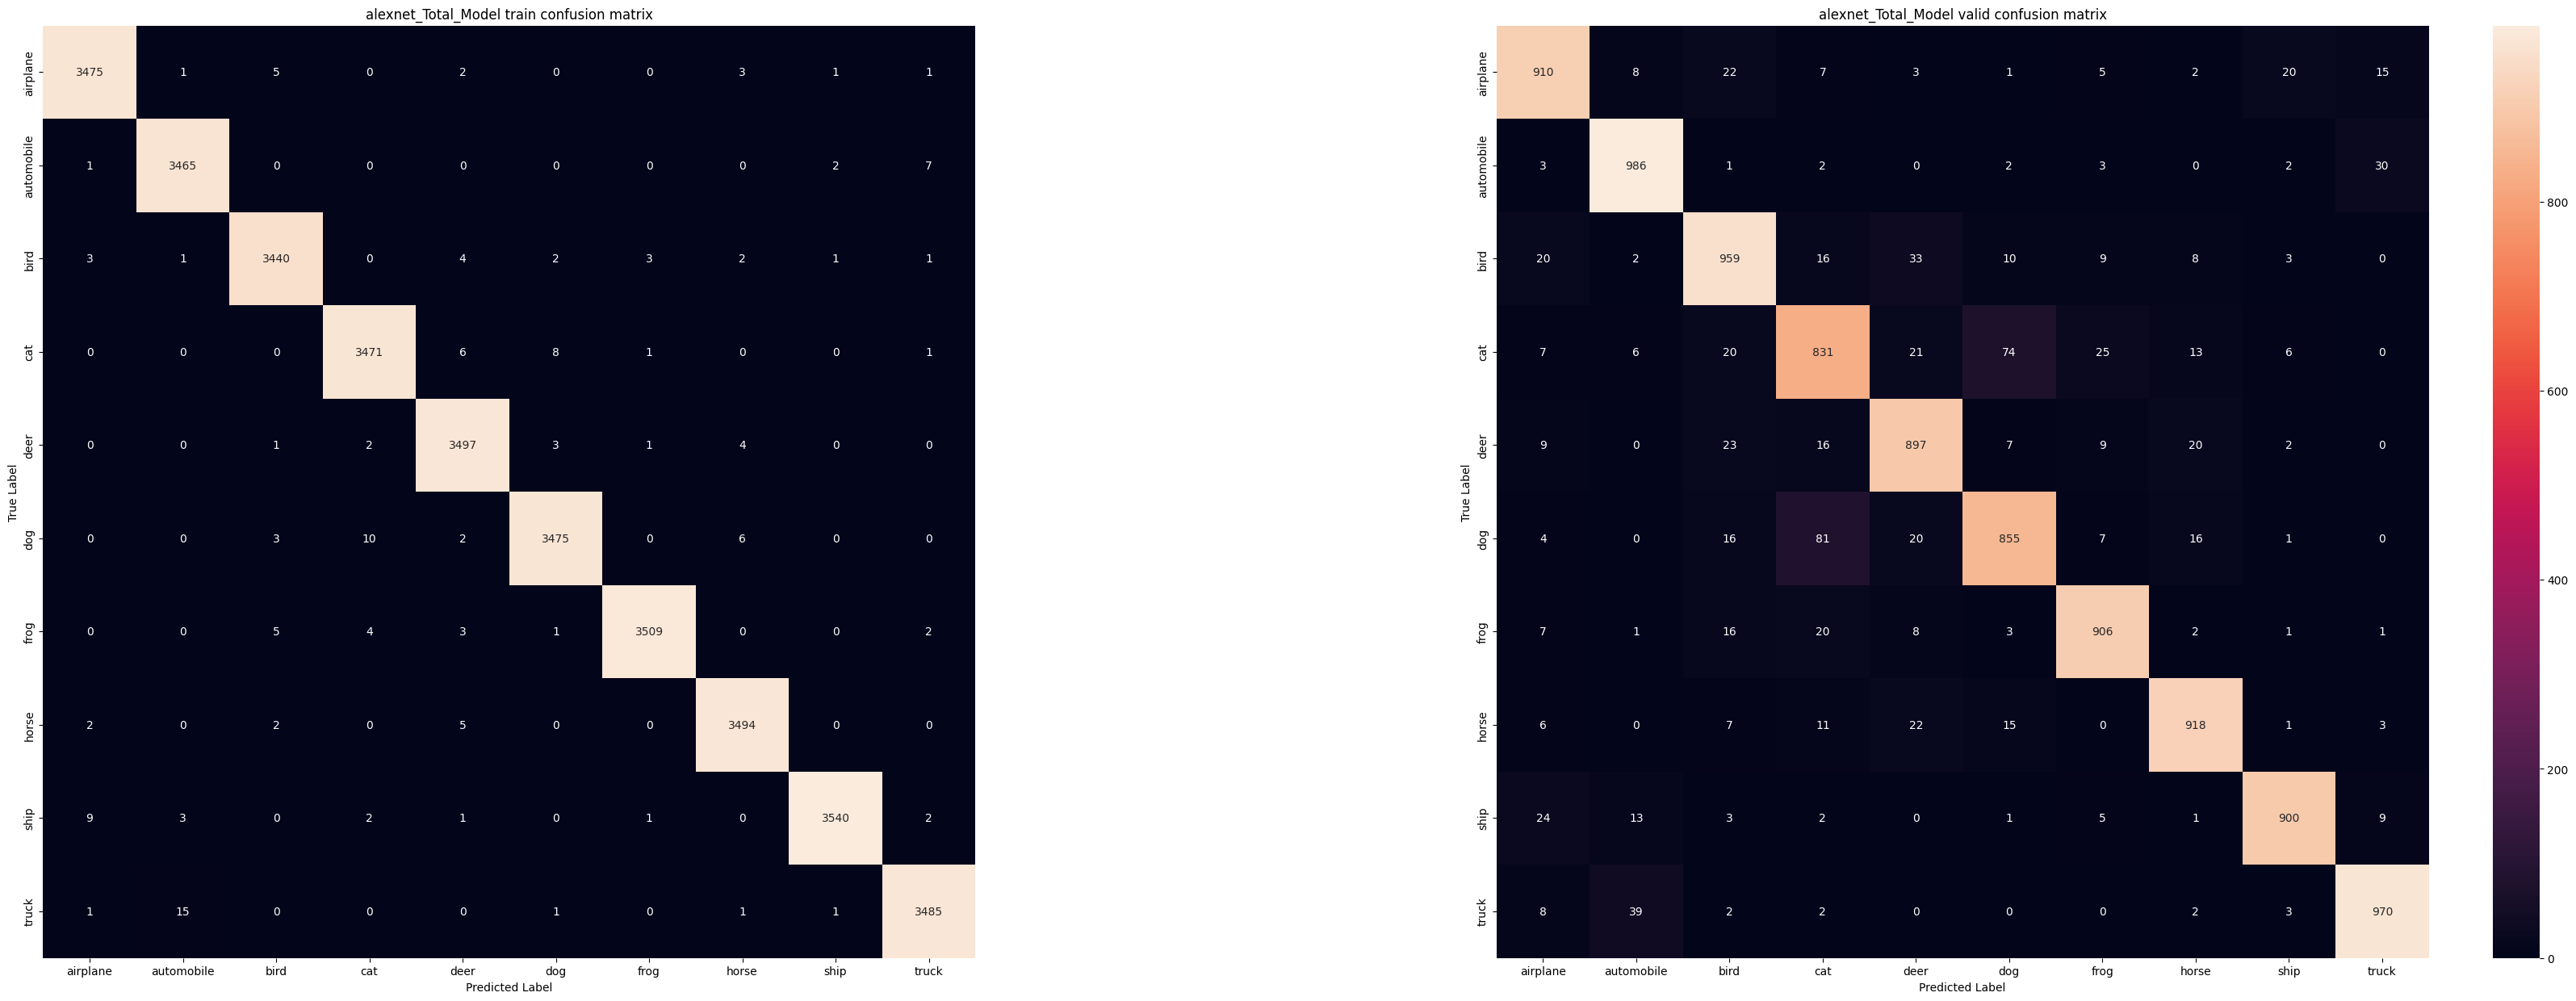

In [44]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

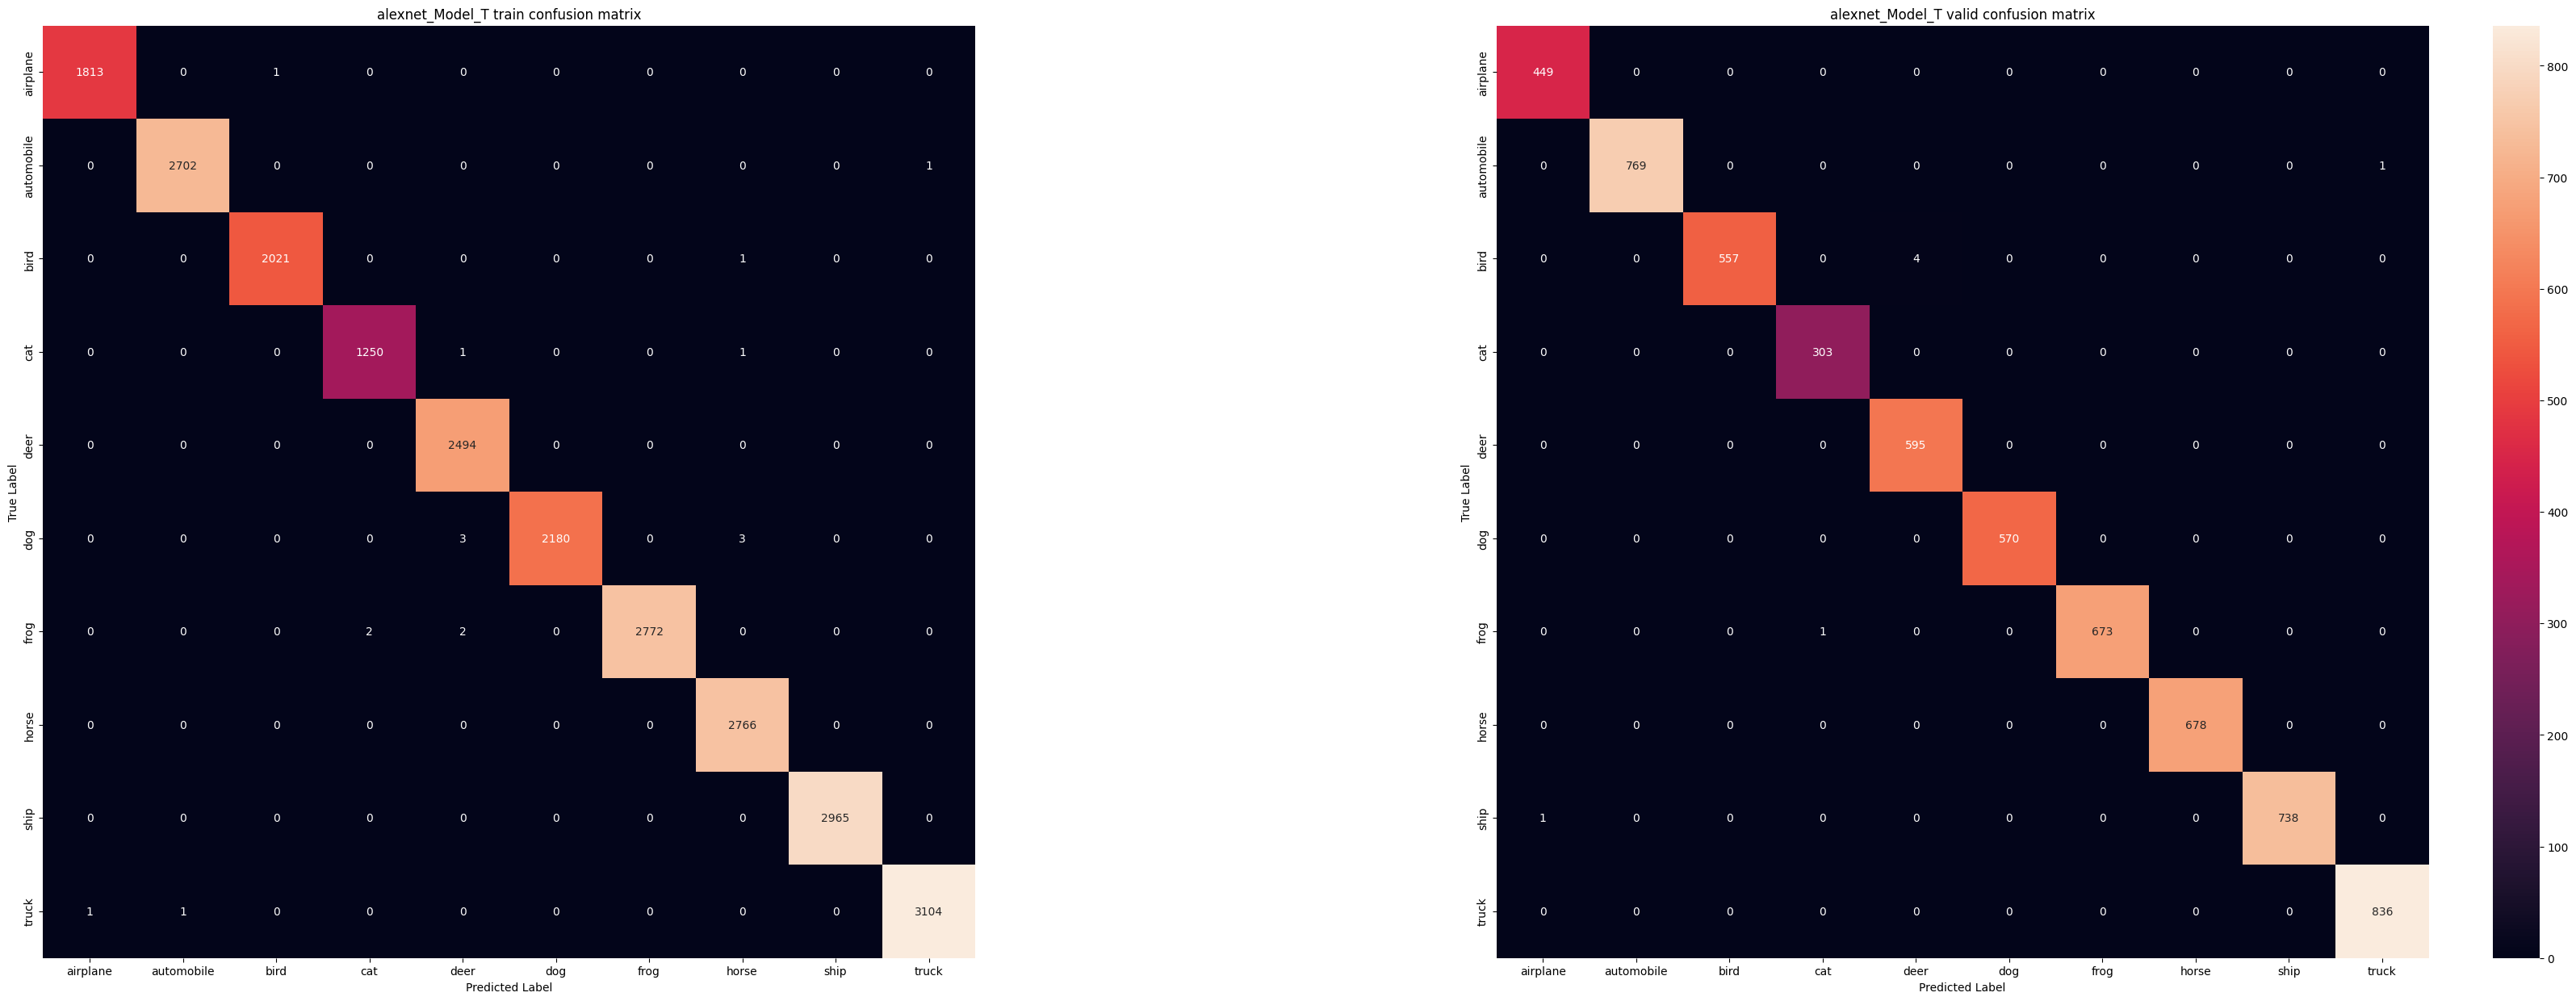

In [45]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

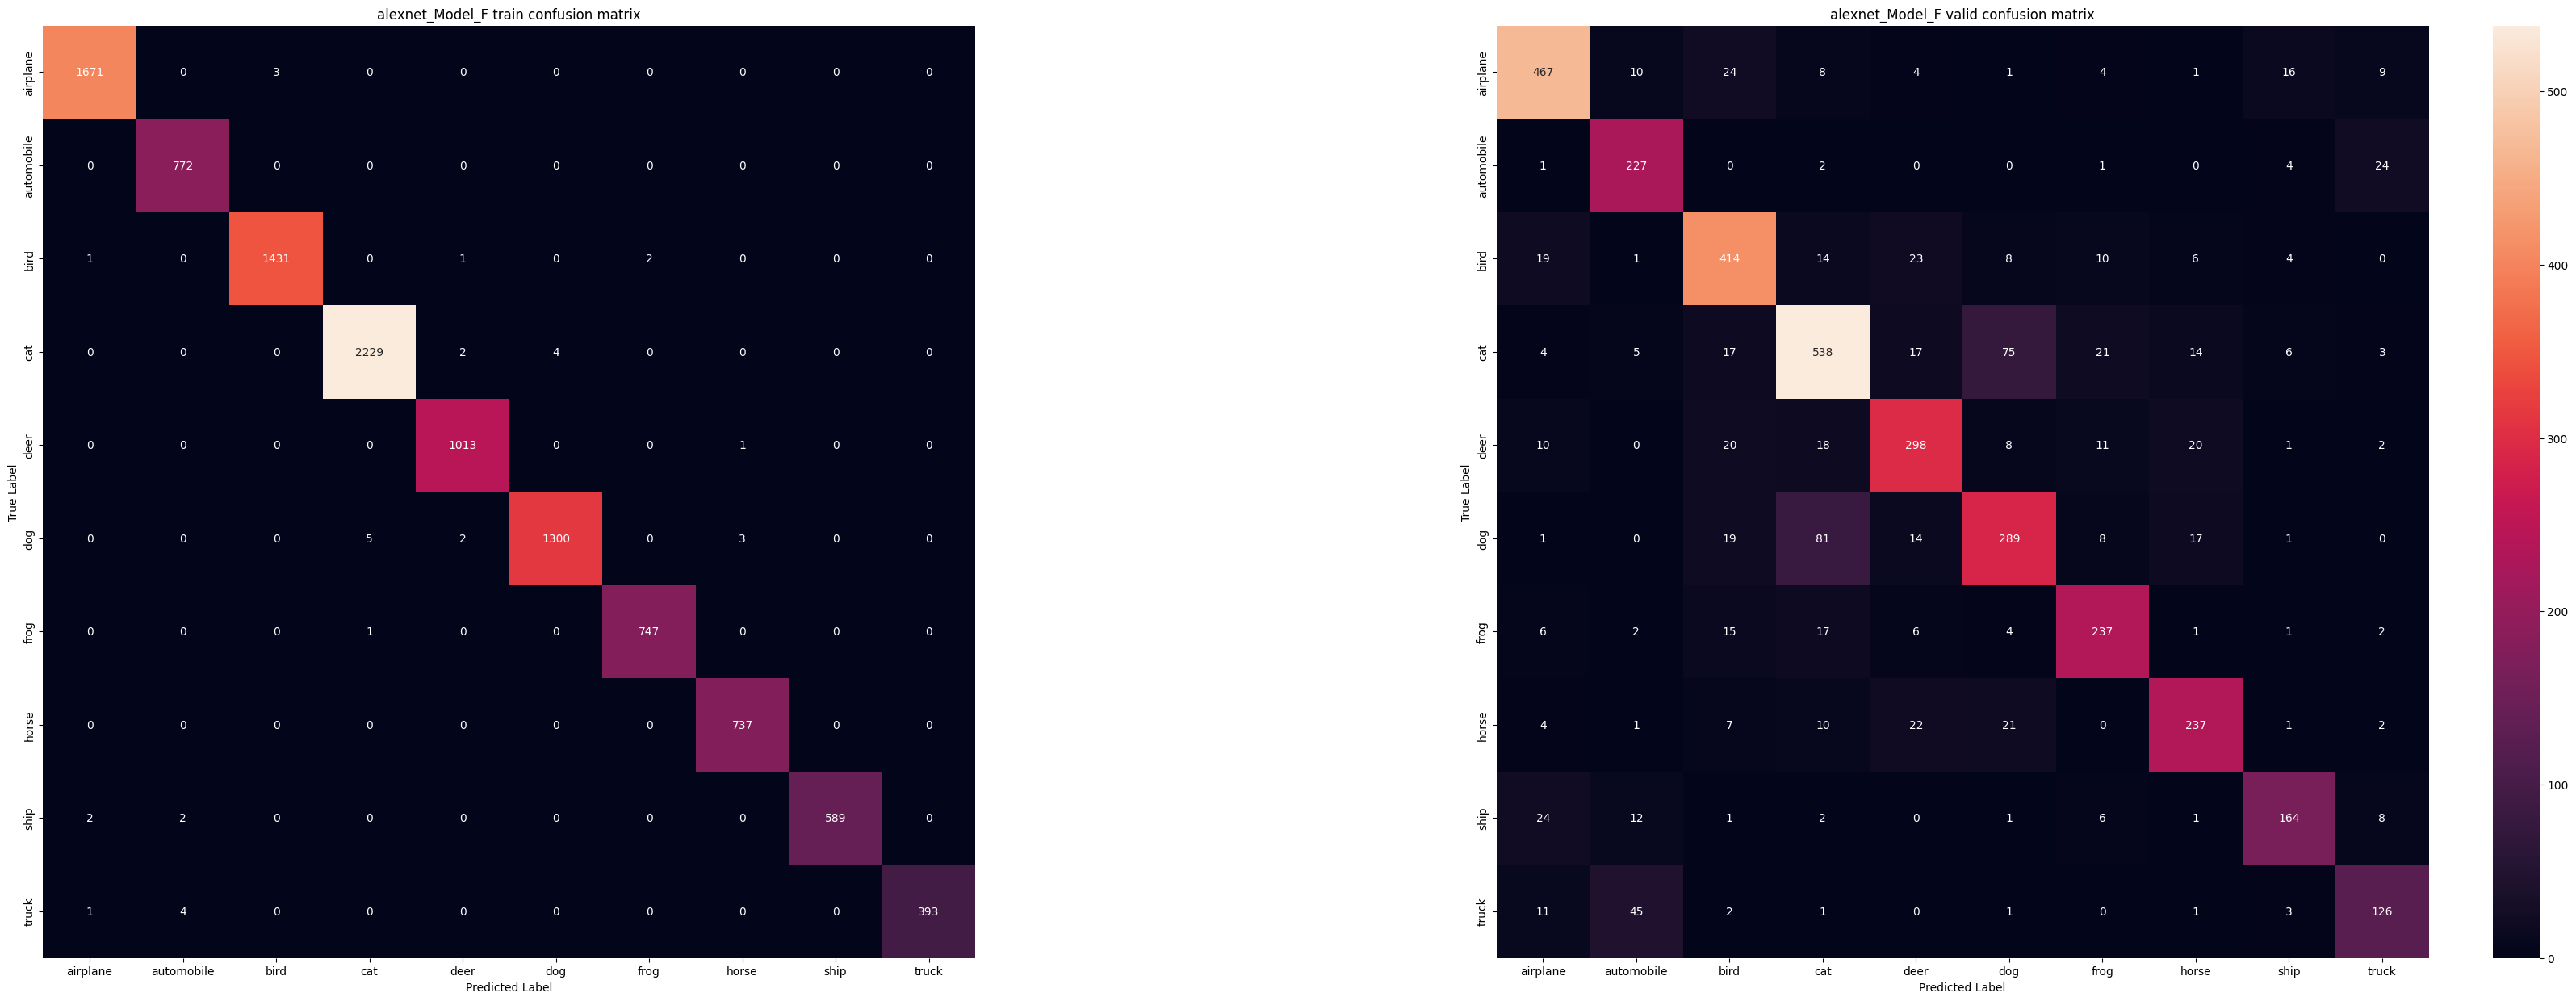

In [46]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)

In [47]:
def show_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                output_F=model_F(d.unsqueeze(0))
                output_T=model_T(d.unsqueeze(0))
                output_0=model_0(d.unsqueeze(0))
                output_decision=model_decision(d.unsqueeze(0))

                pred_F=torch.max(output_F, dim = 1).indices.item()
                pred_T=torch.max(output_T, dim = 1).indices.item()
                pred_0=torch.max(output_0, dim = 1).indices.item()
                pred_decision=torch.max(output_decision, dim = 1).indices.item()

                softmax_F=torch.max(torch.softmax(output_F, dim=1)).item()
                softmax_T=torch.max(torch.softmax(output_T, dim=1)).item()
                softmax_0=torch.max(torch.softmax(output_0, dim=1)).item()
                softmax_decision=torch.max(torch.softmax(output_decision, dim=1)).item()
                
                # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,

                    'Softmax_F': softmax_F,
                    'Softmax_T': softmax_T,
                    'Softmax_0': softmax_0,
                    'Softmax_decision': softmax_decision,
                    
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item(),
                    'Decision':bool(pred_decision),
                    'flag':data_dl.dataset.dataset.flag[idx]

                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [48]:
df_results=show_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
df_results

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,8516,7,7,7,7,1.000000,1.000000,0.999915,0.978790,True,True,True,True,True
1,12278,3,3,3,3,0.999962,1.000000,0.986172,0.729136,True,True,True,False,False
2,10384,7,7,7,7,0.990397,1.000000,0.999021,0.537091,True,True,True,True,True
3,17477,7,7,7,7,0.983161,0.820315,0.935264,0.672673,True,True,True,False,False
4,18728,8,8,8,8,1.000000,1.000000,1.000000,0.999803,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34995,25245,1,1,9,9,0.988119,0.974206,0.727569,0.874395,True,False,False,False,False
34996,26688,3,3,3,3,0.996186,0.999246,0.981962,0.758684,True,True,True,False,False
34997,11668,3,3,3,3,1.000000,1.000000,0.999954,0.975851,True,True,True,True,True
34998,2641,2,2,2,2,1.000000,1.000000,0.999992,0.984097,True,True,True,True,True


In [49]:
df_results[df_results['Decision']!=df_results['flag']]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
11,1405,3,3,3,3,0.999998,0.999999,0.993849,0.580765,True,True,True,False,True
12,26374,9,9,9,9,0.999983,1.000000,0.998644,0.516067,True,True,True,False,True
15,19502,8,8,8,8,0.997464,0.999948,0.861812,0.689124,True,True,True,False,True
27,10800,5,5,5,5,0.999487,0.999999,0.998707,0.746865,True,True,True,False,True
28,41604,2,2,4,2,0.999820,0.592320,0.982719,0.559489,True,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34963,40342,2,2,2,2,0.999088,0.999925,0.981113,0.501105,True,True,True,False,True
34965,41384,3,3,3,3,0.999589,0.999994,0.982269,0.706801,True,True,True,False,True
34972,11191,6,6,6,6,0.999467,0.999985,0.984070,0.727712,True,True,True,True,False
34986,12755,1,1,1,1,0.999999,0.999322,0.910390,0.530580,True,True,True,False,True


In [50]:
df=(df_results[(df_results['Decision']!=df_results['flag']) ])
target_counts = df['Target'].value_counts()
target_counts 

2    581
0    560
3    495
4    467
5    430
7    400
6    391
8    352
1    325
9    234
Name: Target, dtype: int64

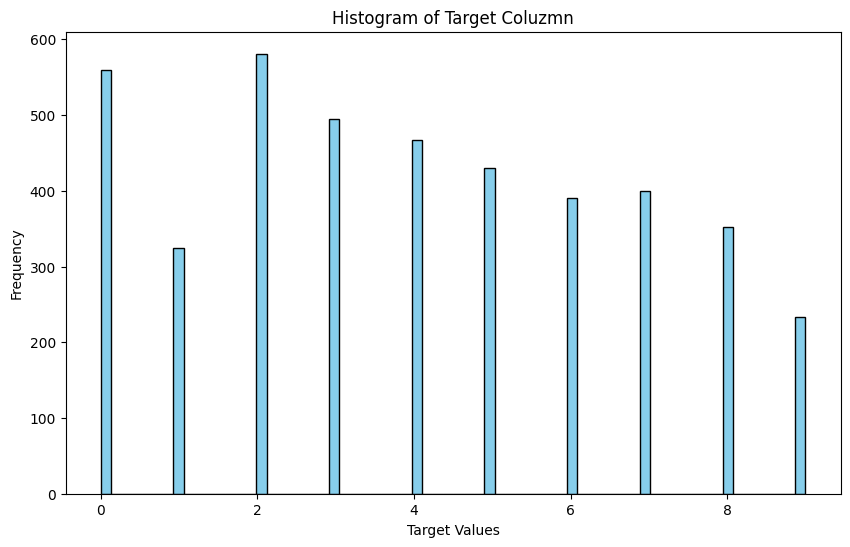

In [51]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Coluzmn')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [52]:
df_results_v=show_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
df_results_v

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,32930,4,4,4,4,1.000000,1.000000,0.999991,0.955970,True,True,True,True,True
1,13698,2,2,4,4,0.816874,0.951277,0.675774,0.866529,True,False,False,False,False
2,30555,9,9,9,9,1.000000,1.000000,0.999998,0.992445,True,True,True,True,True
3,27671,5,5,5,5,1.000000,1.000000,0.999992,0.991165,True,True,True,True,True
4,25446,2,2,2,2,1.000000,1.000000,0.999913,0.850652,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,41256,8,0,0,0,0.998507,0.998249,0.642257,0.843801,False,False,False,False,False
9996,39401,6,0,0,0,0.991309,0.873149,0.865978,0.804949,False,False,False,False,False
9997,29182,9,9,9,9,0.999807,1.000000,0.999954,0.943331,True,True,True,True,True
9998,14447,4,4,4,4,0.999988,1.000000,0.992222,0.752446,True,True,True,True,True


In [53]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
13,46078,1,1,1,1,0.999987,0.999984,0.968945,0.582259,True,True,True,False,True
37,8627,2,2,2,4,0.997175,0.752931,0.530545,0.622302,True,True,False,True,False
39,29407,8,8,8,8,0.999998,1.000000,0.999610,0.541891,True,True,True,True,False
50,25512,2,2,2,2,0.999998,0.994948,0.978768,0.652700,True,True,True,False,True
68,46303,0,0,0,0,0.999857,1.000000,0.990825,0.606782,True,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9944,44861,2,2,2,4,0.998421,0.706904,0.565131,0.735046,True,True,False,False,True
9955,38515,1,1,1,6,0.999137,0.984484,0.786825,0.661470,True,True,False,True,False
9965,31584,3,3,3,3,0.999931,0.999999,0.966980,0.520447,True,True,True,True,False
9970,35034,5,5,5,5,0.997872,0.999981,0.990047,0.551570,True,True,True,True,False


In [54]:
df=df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]
target_counts = df['Target'].value_counts()
target_counts 

2    159
0    151
3    132
6    126
7    124
4    120
5    102
8     93
9     92
1     80
Name: Target, dtype: int64

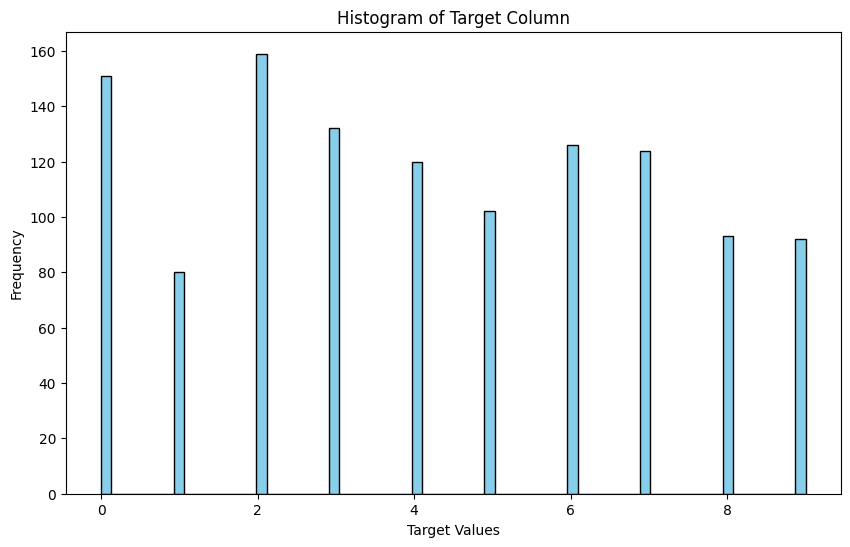

In [55]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Column')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [56]:
#全部模型裝在一起的表現
def total_model_combine_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out_growth = model_0(data)
            softmax_0=torch.softmax(out_growth, dim=1)

            out_T = model_T(data)
            softmax_T=torch.softmax(out_T, dim=1)

            out_F = model_F(data)
            softmax_F=torch.softmax(out_F, dim=1)

         
            
            for s0,st,sf,d in zip(softmax_0,softmax_T,softmax_F,data):
               
                st_max=torch.max(st).item()
                sf_max=torch.max(sf).item()

                out_decision=model_decision(d.unsqueeze(0))
                _, pred = torch.max(out_decision, dim = 1) 
                softmax_decision=torch.max(torch.softmax(out_decision, dim=1))
                
                if(abs(sf_max-st_max)>0.3):
                    # st_max_z=calculate_zscore(st_max,avg_T,max_softmax_T,min_softmax_T)
                    # sf_max_z=calculate_zscore(sf_max,avg_F,max_softmax_F,min_softmax_F)
                
                    if(sf_max>st_max):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1
                else:
                   
                    if(pred==0):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1

            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [57]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_combine_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_loss,accu,sum_F,sum_T

(0.026752922646433166, 0.9956857142857143, 12157, 22843)

In [58]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_combine_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_loss,accu,sum_F,sum_T

(0.42793926075175404, 0.9168, 3676, 6324)

In [59]:
ALL=set(range(10))
targetT=list(ALL-set(targetF))

model_0_embed= copy.deepcopy(model_0)
# model_0_embed.classifier[5]=nn.Identity()
model_0_embed.classifier[6]=nn.Identity()

In [60]:
mean_features_dict_T = {class_idx: [] for class_idx in targetT}
for data, target, idx in Tdl:
    with torch.no_grad():
        data, target = data.to(device), target.to(device)
        out=model_0_embed(data)
        for feature, class_idx in zip(out, target):
            if class_idx not in  targetF:
                mean_features_dict_T[class_idx.item()].append(feature.cpu().view(-1))

# 计算每个 targetF 类别的平均特征向量
mean_features_T = {}
for class_idx, features_list in mean_features_dict_T.items():
    mean_features_T[class_idx] = torch.mean(torch.stack(features_list), dim=0)

In [61]:
mean_features_dict_F = {class_idx: [] for class_idx in targetF}
for data, target, idx in Fdl:
    with torch.no_grad():
        data, target = data.to(device), target.to(device)
        out=model_0_embed(data)
        for feature, class_idx in zip(out, target):
            if class_idx in targetF:
                mean_features_dict_F[class_idx.item()].append(feature.cpu().view(-1))

# 计算每个 targetF 类别的平均特征向量
mean_features_F = {}
for class_idx, features_list in mean_features_dict_F.items():
    mean_features_F[class_idx] = torch.mean(torch.stack(features_list), dim=0)

In [62]:
mean_features_F

{3: tensor([0.0013, 0.1122, 0.0000,  ..., 0.2108, 0.0207, 0.0004]),
 5: tensor([0.0008, 0.1734, 0.0000,  ..., 0.5319, 0.0083, 0.0000]),
 2: tensor([0.0031, 0.1516, 0.0000,  ..., 0.0178, 0.0470, 0.0002]),
 4: tensor([0.0000e+00, 2.1911e-03, 0.0000e+00,  ..., 1.3682e-02, 1.2697e-02,
         3.4343e-05])}

In [63]:
import torch.nn.functional as F
def calculate_sim_max_idx(f,mean_features):
    k=0
    max=0
    for i in mean_features.keys():
        sim=F.cosine_similarity(f,mean_features[i], dim=0)
        if(max<sim):
            k=i
            max=sim
    return k,max

In [64]:
import torch.nn.functional as F
sum_all=0
with torch.no_grad():
    for data,target,idx in train_dl:
 
        data,target=data.to(device),target.to(device)

        out = model_0_embed(data)
     
        for data,t in zip(out,target):
            # print(len(o))
            k_T,similarity_T = calculate_sim_max_idx(data.cpu().view(-1), mean_features_T)
            k_F,similarity_F = calculate_sim_max_idx(data.cpu().view(-1), mean_features_F)
 
            if(similarity_T>similarity_F):
                if(t not in targetF):
                    sum_all+=1
            else:
                if(t in targetF):
                    sum_all+=1

    sum_all=sum_all/train_size
sum_all

0.9845428571428572

In [65]:
import torch.nn.functional as F
sum_all=0
with torch.no_grad():
    for data,target,idx in valid_dl:
 
        data,target=data.to(device),target.to(device)

        out = model_0_embed(data)
     
        for data,t in zip(out,target):
            # print(len(o))
            k_T,similarity_T = calculate_sim_max_idx(data.cpu().view(-1), mean_features_T)
            k_F,similarity_F = calculate_sim_max_idx(data.cpu().view(-1), mean_features_F)
 
            if(similarity_T>similarity_F):
                if(t not in targetF):
                    sum_all+=1
            else:
                if(t in targetF):
                    sum_all+=1

    sum_all=sum_all/valid_size
sum_all

0.9611

In [66]:
#全部模型裝在一起的表現
def total_model_cos_evaluate(data_dl,size,model_0_embed,model_T,model_F):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out = model_0_embed(data)
            # softmax_0=torch.softmax(out_growth, dim=1)
            # _, y_pred = torch.max(out_growth, dim = 1) 
            
            for d,out,t in zip(data,out,target):

                k_T,similarity_T = calculate_sim_max_idx(out.cpu().view(-1), mean_features_T)
                k_F,similarity_F = calculate_sim_max_idx(out.cpu().view(-1), mean_features_F)

                if(similarity_T>similarity_F):
                    out_T = model_T(d.unsqueeze(0))
                    outputs.append(out_T)
                    sum_T+=1
                else:
                    out_F = model_F(d.unsqueeze(0))
                    outputs.append(out_F)
                    sum_F+=1
            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [67]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_cos_evaluate(train_dl,train_size,model_0_embed,model_T,model_F)
total_loss,accu,sum_F,sum_T

(0.09335500622919395, 0.9794857142857143, 14015, 20985)

In [68]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_cos_evaluate(valid_dl,valid_size,model_0_embed,model_T,model_F)
total_loss,accu,sum_F,sum_T

(0.4634233130212873, 0.9068, 4076, 5924)

In [69]:
def choose_with_model(data):
    out_decision=model_decision(data)
    _, pred = torch.max(out_decision, dim = 1) 
    softmax_decision=torch.max(torch.softmax(out_decision, dim=1))
    if(pred==0):
        return 0
    else:
        return 1

In [70]:
def choose_with_softmax(data):
    out_T = model_T(data)
    softmax_T=torch.softmax(out_T, dim=1)

    out_F = model_F(data)
    softmax_F=torch.softmax(out_F, dim=1)

    st_max=torch.max(softmax_T).item()
    sf_max=torch.max(softmax_F).item()

    if(sf_max>st_max):
        return 0
    else:
        return 1

In [71]:
def choose_with_sim(out,mean_features_T,mean_features_F):
    k_T,similarity_T = calculate_sim_max_idx(out.cpu().view(-1), mean_features_T)
    k_F,similarity_F = calculate_sim_max_idx(out.cpu().view(-1), mean_features_F)
    if(similarity_T>similarity_F):
        return 1
    else:
        return 0


In [72]:
#全部模型裝在一起的表現
def total_model_decision_evaluate(data_dl,size,model_0_embed,model_T,model_F):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out = model_0_embed(data)
            # softmax_0=torch.softmax(out_growth, dim=1)
            # _, y_pred = torch.max(out_growth, dim = 1) 
            
            for d,out,t in zip(data,out,target):

                sim_decision=choose_with_sim(out,mean_features_T,mean_features_F)
                soft_decision=choose_with_softmax(d.unsqueeze(0))
                mo_decision=choose_with_model(d.unsqueeze(0))
                total_decision=sim_decision+soft_decision+mo_decision

                if(total_decision>=2):
                    out_T = model_T(d.unsqueeze(0))
                    outputs.append(out_T)
                    sum_T+=1
                else:
                    out_F = model_F(d.unsqueeze(0))
                    outputs.append(out_F)
                    sum_F+=1
            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [73]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_decision_evaluate(train_dl,train_size,model_0_embed,model_T,model_F)
total_loss,accu,sum_F,sum_T

(0.04873310972122708, 0.9932285714285715, 10064, 24936)

In [74]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_decision_evaluate(valid_dl,valid_size,model_0_embed,model_T,model_F)
total_loss,accu,sum_F,sum_T

(0.4663429958447814, 0.9152, 2966, 7034)

In [75]:
# 计算并打印每个数据点的平均边际效应
def calculate_ame_per_sample(model, data_loader, delta=1e-5):
    model.eval()
    ames = []
    idxs=[]
    with torch.no_grad():
        for inputs, _,idx in data_loader:
            inputs = inputs.to(device)
            base_preds = model(inputs).cpu().numpy()

            batch_ames = []
            
            for i in range(inputs.shape[1]):  # 对每个通道计算边际效应
                inputs_delta = inputs.clone()
                inputs_delta[:, i, :, :] += delta
                delta_preds = model(inputs_delta).cpu().numpy()
                ame = (delta_preds - base_preds) / delta
                batch_ames.append(ame)

            batch_ames = np.stack(batch_ames, axis=1)  # (batch_size, num_channels, num_classes)
            batch_ames = np.mean(batch_ames, axis=(1, 2))
            
            ames.append(batch_ames)
            idxs.extend(idx.cpu().numpy())

    ames = np.concatenate(ames, axis=0)  # (num_samples, num_channels, num_classes)
    return idxs,ames



In [76]:
# 计算并打印平均边际效应
idxs,ames = calculate_ame_per_sample(model_F, Fdl)
sorted_indices = np.argsort(ames)[::-1]  # 从大到小排序
sorted_indices
keep_ratio = 0.95 # 保留50%的数据点
num_keep = int(len(sorted_indices) * keep_ratio)
filtered_indices = sorted_indices[:num_keep]
filter_idxs=[]
for i in filtered_indices:
    filter_idxs.append(idxs[i])
    
# 重新加载和预处理训练数据集，使用剔除后的数据点
filtered_Fdataset = Subset(images, filter_idxs)
filtered_Fdl= DataLoader(filtered_Fdataset, shuffle=True, batch_size=batch_size)

Epoch=0,train_loss=0.18962625717524648,train_accu=0.9412729026036644
Epoch=0,valid_loss=0.7216339156362745,valid_accu=0.7657516339869281
0
Epoch=1,train_loss=0.1180579003022055,train_accu=0.9670202507232402
Epoch=1,valid_loss=0.7224838519563862,valid_accu=0.7678431372549019
0
Epoch=2,train_loss=0.09112432338694773,train_accu=0.973963355834137
Epoch=2,valid_loss=0.7750209554348116,valid_accu=0.7657516339869281
Epoch=3,train_loss=0.06510436905345007,train_accu=0.9837994214079074
Epoch=3,valid_loss=0.7799902643876917,valid_accu=0.7675816993464052
Epoch=4,train_loss=0.04398029561845178,train_accu=0.9895853423336548
Epoch=4,valid_loss=0.8119599248225393,valid_accu=0.7712418300653595
0
Epoch=5,train_loss=0.030001274107173157,train_accu=0.9936354869816779
Epoch=5,valid_loss=0.8175714915873957,valid_accu=0.7803921568627451
0
Epoch=6,train_loss=0.01880271062326753,train_accu=0.996046287367406
Epoch=6,valid_loss=0.8161054962756586,valid_accu=0.7764705882352941
Epoch=7,train_loss=0.02365316601547

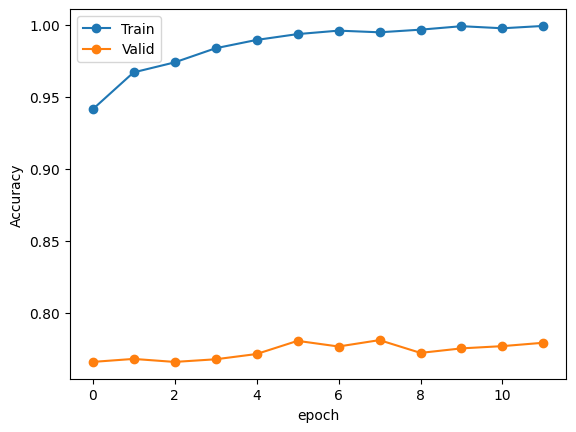

In [77]:
model_F_filter=model_train(model_algo,filtered_Fdl,Fdl_v,"F_f",70)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [78]:
# 计算并打印平均边际效应
idxs,ames = calculate_ame_per_sample(model_T, Tdl)
sorted_indices = np.argsort(ames)[::-1]  # 从大到小排序
sorted_indices
keep_ratio = 0.9  # 保留50%的数据点
num_keep = int(len(sorted_indices) * keep_ratio)
filtered_indices = sorted_indices[:num_keep]
filter_idxs=[]
for i in filtered_indices:
    filter_idxs.append(idxs[i])
    
# 重新加载和预处理训练数据集，使用剔除后的数据点
filtered_Tdataset = Subset(images, filter_idxs)
filtered_Tdl= DataLoader(filtered_Tdataset, shuffle=True, batch_size=batch_size)

Epoch=0,train_loss=0.0074970298561988875,train_accu=0.9976931949250288
Epoch=0,valid_loss=0.00923022338647894,valid_accu=0.9969230769230769
0
Epoch=1,train_loss=0.0036832123325929687,train_accu=0.9988927335640139
Epoch=1,valid_loss=0.003529665302081662,valid_accu=0.9991902834008097
0
Epoch=2,train_loss=0.00145333323570237,train_accu=0.9995386389850057
Epoch=2,valid_loss=0.006525235895018642,valid_accu=0.9985425101214574
Epoch=3,train_loss=0.002790493105986004,train_accu=0.999123414071511
Epoch=3,valid_loss=0.00397183123147993,valid_accu=0.9990283400809716
Epoch=4,train_loss=0.0020482252861665595,train_accu=0.9993079584775086
Epoch=4,valid_loss=0.006219457584736344,valid_accu=0.9985425101214574
Epoch=5,train_loss=0.0007333004518219218,train_accu=0.9997231833910034
Epoch=5,valid_loss=0.0020161862395318385,valid_accu=0.9995141700404858
0
Epoch=6,train_loss=0.0003942900715832718,train_accu=0.9998615916955017
Epoch=6,valid_loss=0.009009659637825044,valid_accu=0.9982186234817814
Epoch=7,trai

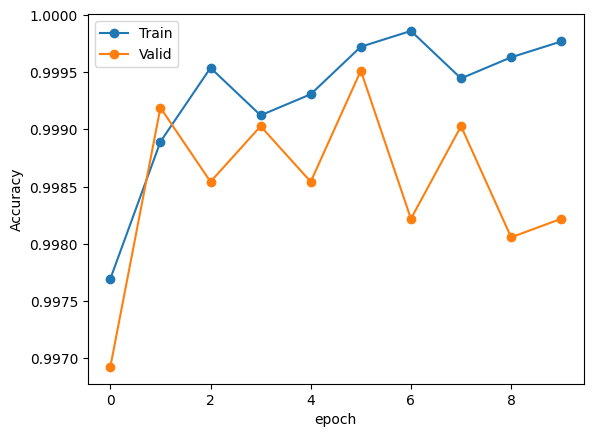

In [79]:
model_T_filter=model_train(model_algo,filtered_Tdl,Tdl_v,"T_f",70)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [80]:
F_loss_f,F_accu_f,confusion_matrix_F_train_f=evaluate_model(model_F_filter,Fdl,len(Fdataset),'F',mode='eval')
F_valid_loss_f,F_valid_accu_f,confusion_matrix_F_valid_f=evaluate_model(model_F_filter,Fdl_v,len(Fdataset_v),'F',mode='eval')

In [81]:
T_loss_f,T_accu_f,confusion_matrix_T_train_f=evaluate_model(model_T_filter,Tdl,len(Tdataset),'T',mode='eval')
T_valid_loss_f,T_valid_accu_f,confusion_matrix_T_valid_f=evaluate_model(model_T_filter,Tdl_v,len(Tdataset_v),'T',mode='eval')

In [82]:
total_train_loss_f,total_train_accu_f,confusion_matrix_total_train_f,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T_filter,model_F_filter,model_decision)
total_valid_loss_f,total_valid_accu_f,confusion_matrix_total_valid_f,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T_filter,model_F_filter,model_decision)

In [83]:
train_losses=[train_loss,decision_loss,T_loss_f,F_loss_f,total_train_loss_f,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu_f,F_accu_f,total_train_accu_f,total_train_accu_d]
valid_losses=[valid_loss,decision_valid_loss,T_valid_loss_f,F_valid_loss_f,total_valid_loss_f,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu_f,F_valid_accu_f,total_valid_accu_f,total_valid_accu_d]

In [84]:
model_algos=['Model_0','Model_Decision',"Model_T_f","Model_F_f","Total_Model_f",'Total_Model_without_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
print(f'targetF={targetF}')
df

targetF=[3, 5, 2, 4]


,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.084117,0.974086,0.288269,0.904500
1,Model_Decision,0.298853,0.879114,0.278329,0.884300
2,Model_T_f,0.000714,0.999834,0.002976,0.998543
3,Model_F_f,0.029505,0.992030,0.912519,0.776993
4,Total_Model_f,0.028137,0.993943,0.405829,0.910700
5,Total_Model_without_decision,0.007120,0.998257,0.329063,0.917800
